In [2]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
from langchain_core.tools import tool


In [43]:
from langchain_tavily import TavilySearch
tavily_search = TavilySearch(
    max_results=2,
    topic="general",
    include_answer=True
)
@tool
def web_search(query:str) -> str:

    """
    Uses tavily tool to search the web for up-to-date information and returns relevant results with sources.
    """

    return tavily_search.invoke({"query":query})['answer']
# web_search("what is recent ai news")

In [74]:
web_search.invoke("what are guardrails")

'Guardrails are safety measures in AI systems to prevent harmful or inappropriate content and ensure ethical responses. They enforce rules and policies to maintain security and predictability.'

In [94]:
from langchain_groq import ChatGroq
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0
    # model should always return structured output
)


In [95]:
llm.invoke("hi")

AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 36, 'total_tokens': 44, 'completion_time': 0.006555201, 'completion_tokens_details': None, 'prompt_time': 0.00167347, 'prompt_tokens_details': None, 'queue_time': 0.04872455, 'total_time': 0.008228671}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fe581-0b41-7221-ba3e-fd250a3e4082-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 8, 'total_tokens': 44})

### Input Context

#### System Prompt

In [5]:
from deepagents import create_deep_agent
from deepagents.backends import StateBackend

# Files are saved in langgraph state

# By default we provide a StateBackend
agent = create_deep_agent(
    model=llm,
    system_prompt=(
        "You are a reearch assistant specialising in scientific literature."
        "Always cite sources. Use subagents for parallel research on different topics."
    )
    )



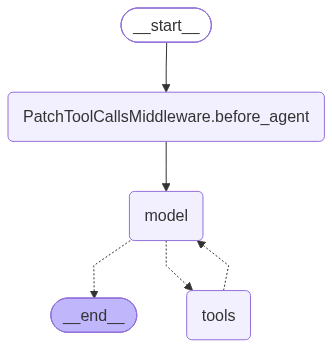

In [5]:
agent

##### Memory
###### Final prompt sent to LLM - 
###### System prompt(static and tells tone, behaviour) + memory files + user query

In [6]:
from langgraph.checkpoint.memory import MemorySaver
checkpointer = MemorySaver()

In [35]:
from deepagents import create_deep_agent
# from deepagents.backends import StateBackend

# Files are saved in langgraph state

# By default we provide a StateBackend
agent = create_deep_agent(
    model=llm,
    checkpointer=checkpointer
    )



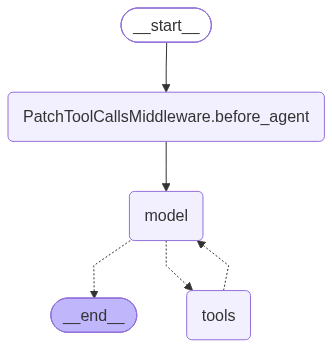

In [8]:
agent

In [7]:
from deepagents import create_deep_agent
# from deepagents.backends import StateBackend

# Files are saved in langgraph state

# By default we provide a StateBackend
agent = create_deep_agent(
    model=llm,
    memory=["projects/AGENTS.md"],
    checkpointer=checkpointer,

    )



In [41]:
agents_md="""
# Agent Profile & Memory

This file gives the agent background knowledge about its own architectire, the project conventions and how it should operate.

## Project Overview

This repository contains an AI application built with LangGraph and FastAPI.

The primary goals are:
- Write clean, maintainable code.
- Prefer simple solutions over complex ones.
- Keep changes minimal and focused.
- Preserve existing behavior unless explicitly requested.

---

## Coding Standards

- Follow PEP 8.
- Use type hints whenever possible.
- Write descriptive variable and function names.
- Keep functions under 50 lines when practical.
- Avoid duplicate code.

---

## File Organization

- API routes belong in `app/api/`
- Business logic belongs in `app/services/`
- Utility functions belong in `app/utils/`
- Database code belongs in `app/db/`

Do not create new top-level directories unless necessary.

---

## Python Guidelines

- Use pathlib instead of os.path.
- Prefer dataclasses or Pydantic models.
- Avoid global variables.
- Use logging instead of print().
- Raise meaningful exceptions.

---

## Testing

Whenever modifying code:

- Update existing tests if needed.
- Add tests for new functionality.
- Run the relevant tests before finishing.
- Do not remove tests unless requested.

---

## Dependencies

Prefer existing libraries already used in the project.

Do not introduce new dependencies unless they provide significant value.

---

## Git

Do not modify:

- .gitignore
- LICENSE
- README.md

unless explicitly instructed.

---

## Security

Never:

- Hardcode API keys
- Commit secrets
- Disable authentication
- Log passwords or tokens

Use environment variables for secrets.

---

## Documentation

When adding a new module:

- Add a module docstring.
- Document public functions.
- Update README only if requested.

---

## Error Handling

Prefer explicit exception handling.

Return informative error messages while avoiding leakage of sensitive information.

---

## Performance

Avoid unnecessary database queries.

Avoid loading large files entirely into memory.

Prefer generators when processing large datasets.

---

## Before Finishing

Verify:

- Code compiles.
- Imports are correct.
- No unused variables.
- No obvious bugs.
- Formatting is clean.

Provide a brief summary of the changes made.
"""

In [10]:
from deepagents.backends.utils import create_file_data
create_file_data(agents_md)

NameError: name 'agents_md' is not defined

In [45]:
result=agent.invoke({
    "messages":[
        {
            "role":"user",
            "content":"What is in your memory?"
        }
       
    ],
     "files":{"projects/AGENTS.md":create_file_data(agents_md)}
},
config={"configurable":{"thread_id":"2"}}
)

In [46]:
result

{'messages': [HumanMessage(content='What is in your memory?', additional_kwargs={}, response_metadata={}, id='523f842c-0c62-4f45-8561-9b6f98946e06'),
  AIMessage(content='My memory contains the following key pieces of information:\n\n1. **Agent Profile & Memory**  \n   - The contents of `projects/AGENTS.md`, which describe the project overview, coding standards, file organization, Python guidelines, testing conventions, dependency handling, Git rules, security best practices, documentation rules, error handling, performance tips, and the “before finishing” checklist.\n\n2. **Memory Guidelines**  \n   - The rules for how I should learn from user interactions, when to update memory, what to avoid storing, and how to handle feedback and new patterns.\n\n3. **Tool Definitions**  \n   - The full list and descriptions of the available tools (`ls`, `read_file`, `write_file`, `edit_file`, `delete`, `glob`, `grep`, `task`) and how to use them.\n\nThese are the primary items retained in my inter

In [47]:
from deepagents.backends.store import StoreBackend
from langgraph.store.memory import InMemoryStore

store=InMemoryStore()

store.put(("memories"),"AGENTS.md", create_file_data(agents_md))

store_agent=create_deep_agent(
    model=llm,
    backend=StoreBackend(store=store,namespace=lambda rt:("memories")),
    memory=["/projects/AGENTS.md"],
    store=store,
    checkpointer=checkpointer
)

In [48]:
result=store_agent.invoke({
     "messages":[
            {
                "role":"user",
                "content":"What is in your memory?"
            }
           
        ]
    },
    config={"configurable":{"thread_id":"2"}}
    
)

In [49]:
result

{'messages': [HumanMessage(content='What is in your memory?', additional_kwargs={}, response_metadata={}, id='523f842c-0c62-4f45-8561-9b6f98946e06'),
  AIMessage(content='My memory contains the following key pieces of information:\n\n1. **Agent Profile & Memory**  \n   - The contents of `projects/AGENTS.md`, which describe the project overview, coding standards, file organization, Python guidelines, testing conventions, dependency handling, Git rules, security best practices, documentation rules, error handling, performance tips, and the “before finishing” checklist.\n\n2. **Memory Guidelines**  \n   - The rules for how I should learn from user interactions, when to update memory, what to avoid storing, and how to handle feedback and new patterns.\n\n3. **Tool Definitions**  \n   - The full list and descriptions of the available tools (`ls`, `read_file`, `write_file`, `edit_file`, `delete`, `glob`, `grep`, `task`) and how to use them.\n\nThese are the primary items retained in my inter

In [50]:
from deepagents.backends.filesystem import FilesystemBackend

fs_agent = create_deep_agent(
    model=llm,
    backend = FilesystemBackend(root_dir="projects", virtual_mode=True),
    memory=["AGENTS.md"],
    checkpointer=checkpointer
)

In [51]:
result=fs_agent.invoke({
      "messages":[
                {
                    "role":"user",
                    "content":"Do you have a memory?"
                }
               
            ]
        },
        config={"configurable":{"thread_id":"2"}}
)

In [52]:
result

{'messages': [HumanMessage(content='What is in your memory?', additional_kwargs={}, response_metadata={}, id='523f842c-0c62-4f45-8561-9b6f98946e06'),
  AIMessage(content='My memory contains the following key pieces of information:\n\n1. **Agent Profile & Memory**  \n   - The contents of `projects/AGENTS.md`, which describe the project overview, coding standards, file organization, Python guidelines, testing conventions, dependency handling, Git rules, security best practices, documentation rules, error handling, performance tips, and the “before finishing” checklist.\n\n2. **Memory Guidelines**  \n   - The rules for how I should learn from user interactions, when to update memory, what to avoid storing, and how to handle feedback and new patterns.\n\n3. **Tool Definitions**  \n   - The full list and descriptions of the available tools (`ls`, `read_file`, `write_file`, `edit_file`, `delete`, `glob`, `grep`, `task`) and how to use them.\n\nThese are the primary items retained in my inter

In [8]:
from urllib.request import urlopen
from pathlib import Path
from langchain_quickjs import CodeInterpreterMiddleware

ModuleNotFoundError: No module named 'langchain_quickjs'

In [19]:
checkpointer=MemorySaver()
backend=StateBackend()

skill_dirs=["langgraph","python","aws","report-writer"]
skills_files={
    f"/skills/{name}/skill.md":create_file_data(
        Path( f"skills/{name}/skill.md").read_text(encoding="utf-8")
    )

    for name in skill_dirs
}

In [31]:
skills_files

{'/skills/langgraph/skill.md': {'content': '# LangGraph Development Skill\n\n## Purpose\n\nThis skill enables the agent to design, implement, debug, optimize, and explain LangGraph applications.\n\nThe objective is to build production-quality, maintainable, and scalable graph-based AI systems using LangGraph, LangChain, and modern LLM engineering practices.\n\nThis skill should be activated whenever the user asks about LangGraph, AI agents, workflows, orchestration, multi-agent systems, tool calling, checkpoints, persistence, memory, or graph execution.\n\n---\n\n## Scope\n\nThis skill covers:\n\n- StateGraph\n- MessageGraph\n- Graph architecture\n- Nodes\n- Edges\n- Conditional routing\n- Reducers\n- Typed State\n- MessagesState\n- Commands\n- Interrupts\n- Human-in-the-loop\n- Checkpointing\n- Persistence\n- Memory\n- ToolNode\n- Tool Calling\n- Streaming\n- Parallel execution\n- Multi-agent workflows\n- RAG pipelines\n- Deep Agents\n- Supervisor architectures\n- Subgraphs\n- LangSmi

In [40]:
agent=create_deep_agent(
    model=llm,
    backend=backend,
    skills=["/skills/"],
    checkpointer=checkpointer,
    system_prompt="Make use of relevant skills and memory if provided and if needed"
)

In [ ]:
result=agent.invoke({
    "messages":[
        {
            "role":"user",
            "content":"What skills do you have available?"
        }
       
    ],
     "files":skills_files
},
config={"configurable":{"thread_id":"1"}}
)

In [23]:
result

{'messages': [HumanMessage(content='What skills do you have available?', additional_kwargs={}, response_metadata={}, id='71c008eb-054e-4782-9246-dee8f66fb5f8'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "We need to list available skills. The system says no skills available yet. But we might list skills library. Let's list directory /skills/.", 'tool_calls': [{'id': 'fc_66369798-b7ce-493c-8f88-191011094c78', 'function': {'arguments': '{"path":"/skills/"}', 'name': 'ls'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 54, 'prompt_tokens': 2090, 'total_tokens': 2144, 'completion_time': 0.05425817, 'completion_tokens_details': {'reasoning_tokens': 29}, 'prompt_time': 0.203969187, 'prompt_tokens_details': None, 'queue_time': 0.26075307, 'total_time': 0.258227357}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_92d51d08e5', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq

In [25]:
print(result["messages"][-1].content)

I currently have four specialized skill modules available:

| Skill | Purpose | Typical Activation Triggers |
|-------|---------|-----------------------------|
| **AWS Cloud Engineering** (`/skills/aws/skill.md`) | Design, deploy, troubleshoot, and optimise AWS‑based cloud solutions while following the AWS Well‑Architected Framework. | Any request about AWS services, cloud architecture, DevOps, networking, security, cost‑optimisation, or related topics. |
| **LangGraph Development** (`/skills/langgraph/skill.md`) | Build, debug, optimise, and explain LangGraph‑based AI workflows, including state management, tool calling, persistence, and multi‑agent orchestration. | Any request involving LangGraph, LangChain integration, AI agent orchestration, or graph‑based workflow design. |
| **Python Development** (`/skills/python/skill.md`) | Produce production‑ready, readable, maintainable Python code for a wide range of tasks (scripts, APIs, automation, testing, async, etc.). | Any request for 

In [41]:
result=agent.invoke({
    "messages":[
        {
            "role":"user",
            "content":"Create a workflow in langgraph."
        }
       
    ],
     "files":skills_files
},
config={"configurable":{"thread_id":"4"}}
)

In [42]:
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Create a workflow in langgraph.
================================== Ai Message ==================================
Tool Calls:
  write_file (fc_fdc9c55f-f82c-4b33-89fd-10d7f8417687)
 Call ID: fc_fdc9c55f-f82c-4b33-89fd-10d7f8417687
  Args:
    content: # langgraph_workflow.py
"""
A minimal example of a LangGraph workflow that takes a user question and returns a response from an LLM.

Requirements:
- langgraph
- langchain
- openai (for ChatOpenAI)

This script demonstrates how to define a state, nodes, and a graph.
"""

from typing import List

from langchain.chat_models import ChatOpenAI
from langgraph.graph import StateGraph, State, END

# Define the state that will flow through the graph.
class MyState(State):
    messages: List[dict]  # Each message is a dict with 'role' and 'content'

# A simple node that calls the LLM with the current messages and appends the response.
async def llm_node(state: MyState

### Subagents turn one generalist agent into a team of specialists

In [76]:
research_subagent={
    "name":"research-subagent",
   "description":"ALWAYS use this subagent whenever the user asks to research,investigate, compare, summarize information from multiple sources, or requires web search.",
   "system_prompt":"You are a great researcher",
   "tools": [web_search],
   "model":llm
}

In [77]:
subagents=[research_subagent]

In [78]:
agent=create_deep_agent(
    model=llm,
    subagents=subagents,
    system_prompt="Always ake use of subagents for the tasks they are delegated for."
)

In [79]:
result=agent.invoke({
    "messages":[
        {
            "role":"user",
            "content":"Research about Guardrails and give me a detailed summary."
        }
       
    ]
    #  "files":skills_files
},
config={"configurable":{"thread_id":"500"}}
)

BadRequestError: Error code: 400 - {'error': {'message': "Parsing failed. The model generated output that could not be parsed. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'output_parse_failed', 'failed_generation': ''}}

In [69]:
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Research about Guardrails and give me a detailed summary.
================================== Ai Message ==================================
Tool Calls:
  grep (fc_8e530839-a23f-409d-9995-72545541bb74)
 Call ID: fc_8e530839-a23f-409d-9995-72545541bb74
  Args:
    glob: **/*.md
    output_mode: files_with_matches
    pattern: Guardrails
================================= Tool Message =================================
Name: grep

No matches found
================================== Ai Message ==================================
Tool Calls:
  ls (fc_d07c6d55-c62f-4848-bfc9-f5818bd3475e)
 Call ID: fc_d07c6d55-c62f-4848-bfc9-f5818bd3475e
  Args:
    path: /
================================= Tool Message =================================
Name: ls

No files found
================================== Ai Message ==================================

**Guardrails – A Comprehensive Overview**

---

### 1. What Are Guardrails

In [96]:
from pydantic import BaseModel, Field

class ResearchFinding(BaseModel):
    """Structured findings from a research task"""

    summary:str=Field(description="Summary of findings")
    confidence:float=Field(description="Confidence score from 0 to 1")
    sources:list[str]=Field(description="List of source urls")

    

In [ ]:
research_subagent={
    "name":"research-subagent",
   "description":"ALWAYS use this subagent whenever the user asks to research,investigate, compare, summarize information from multiple sources, or requires web search.",
   "system_prompt":"You are a great researcher",
   "tools": [web_search],
   "model":llm,
   "response_format":ResearchFinding,
#    "files":research_files
}

# agents_md = {
#     "AGENTS.md": create_file_data(
#         Path("AGENTS.md").read_text(encoding="utf-8")
#     )
# }

# research_files = {
#     **agents_md,
#     "skills/research/skill.md": create_file_data(
#         Path("skills/research/skill.md").read_text(encoding="utf-8")
#     ),
# }


In [98]:
subagents=[research_subagent]

In [106]:
agent=create_deep_agent(
    model=llm,
    subagents=subagents,
    system_prompt="Gather the output of all the subagents as needed and give a summarised response on the user query."
)

In [108]:
result=agent.invoke({
    "messages":[
        {
            "role":"user",
            "content":"Research about deepfakes and thereaafter give a summary on the topic."
        }
       
    ]
    #  "files":skills_f iles
},
config={"configurable":{"thread_id":"111"}}
)

KeyError: 'answer'

In [104]:
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Research about deepfakes and thereaafter give a summary on the topic.
================================== Ai Message ==================================
Tool Calls:
  task (37pvam546)
 Call ID: 37pvam546
  Args:
    description: Research deepfakes and provide a summary
    output: summary
    subagent_type: research-subagent
================================= Tool Message =================================
Name: task

{"summary":"Deepfakes, initially used for entertainment, now pose risks like revenge porn and misinformation; research focuses on detection using machine learning, but challenges remain due to evolving techniques.","confidence":0.8,"sources":["https://www.researchgate.net/publication/343944383_Deepfakes_and_their_impact_on_society","https://arxiv.org/abs/2006.13939"]}
================================== Ai Message ==================================

The research subagent has provided a summary on